# F-FLIP correctness check — `eyenet.geometry.flip_for_canonical_eye`

Validates the canonical-eye flip convention (Roadmap F-FLIP / TechStack §Left/Right Flip Convention) against **real** EveDataset bundle samples, composed on top of the already-completed F-NORM warp (`src/eye_norm.py`).

Pipeline per sample: `get_face_crop` → `compose_warp` + `normalize_eye` (F-NORM, 128×128 normalized eye patch) → `flip_for_canonical_eye` (F-FLIP, canonical orientation).

Checks:
1. Eye is determined from the **`W`-patch name** (`left`/`right`), never from `get_eye_coords_in_crop` (opposite convention — see TechStack).
2. Left-eye samples pass through unchanged; right-eye samples are horizontally flipped and their vector's x-component negated.
3. Flip-then-flip recovers the original image and vector exactly (identity).
4. Flipped vectors stay unit-norm.
5. Visual check: gaze arrow direction is consistent with the (possibly mirrored) eye image before and after canonicalization.

In [10]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..") / "src"))

import numpy as np
import matplotlib.pyplot as plt

from evedataset import EveBundle
from eye_norm import compose_warp, normalize_eye
from eyenet.geometry import flip_for_canonical_eye

EVEDATASET_REPO = Path("..") / ".." / "eve_shared" / "EveDataset"
BUNDLE_DIR = EVEDATASET_REPO / "bundle"
CROPS_ROOT = EVEDATASET_REPO / "eve_out"

bundle = EveBundle.load(BUNDLE_DIR)
print(f"Loaded bundle: {len(bundle.samples_df)} experiments")

Loaded bundle: 3096 experiments


## Helper: spherical `(theta, phi)` → 3D unit vector (MPIIGaze convention)

Prototyped here for the notebook only (per Roadmap, this becomes a tested module in R1). Matches Mission.md §Target derivation: `g = [-cos(theta)·sin(phi), -sin(theta), -cos(theta)·cos(phi)]`.

In [11]:
def spherical_to_unit(theta: float, phi: float) -> np.ndarray:
    return np.array(
        [-np.cos(theta) * np.sin(phi), -np.sin(theta), -np.cos(theta) * np.cos(phi)],
        dtype=np.float64,
    )

## Pick real, valid `(exp_key, frame, patch)` samples

Strictest validity gate: `get_frame_validity(exp_key)[frame]` AND `get_warp_matrix(exp_key, patch)["validity"][frame]` (same underlying flag as gaze validity per F9 — see TechStack FR6).

In [12]:
def find_valid_samples(bundle, patch, n=1):
    """Yield (exp_key, frame) pairs valid for the given patch."""
    found = []
    for exp_key in bundle.samples_df["exp_key"]:
        if not (bundle.has_gaze_norm(exp_key) and bundle.has_face_crops(exp_key)):
            continue
        fv = bundle.get_frame_validity(exp_key)
        wm = bundle.get_warp_matrix(exp_key, patch)
        valid = fv & wm["validity"]
        frames = np.nonzero(valid)[0]
        for f in frames:
            found.append((exp_key, int(f)))
            if len(found) >= n:
                return found
    return found


def load_normalized_sample(bundle, exp_key, frame, patch):
    """F-NORM pipeline: face crop -> composed warp -> 128x128 normalized eye patch + target vector.

    `patch` ("left"/"right") is the W-patch name, which shares its frame with
    g_tobii/o -- the ONLY correct way to determine eye identity for F-FLIP
    (never from get_eye_coords_in_crop, which uses the opposite convention).
    """
    crop = bundle.get_face_crop(exp_key, frame, CROPS_ROOT)
    W = bundle.get_warp_matrix(exp_key, patch)["W"][frame]
    x0, y0 = bundle.get_crop_origin(exp_key)[frame]
    H_crop = compose_warp(W, int(x0), int(y0))
    eye_patch = normalize_eye(crop, H_crop)

    g_tobii = bundle.get_normalized_gaze(exp_key, patch)["g_tobii"][frame]
    vector = spherical_to_unit(*g_tobii)
    return eye_patch, vector


left_samples = find_valid_samples(bundle, "left", n=3)
right_samples = find_valid_samples(bundle, "right", n=3)
print("left samples:", left_samples)
print("right samples:", right_samples)

left samples: [('train13_step027', 15), ('train13_step027', 16), ('train13_step027', 17)]
right samples: [('train13_step027', 15), ('train13_step027', 16), ('train13_step027', 17)]


## 1. Visual check — left eye (unflipped) vs. right eye (flipped to canonical)

Gaze arrow drawn from the `(x, y)` components of the vector, before and after canonicalization. For the right eye, the image should mirror horizontally and the arrow's horizontal component should flip sign.

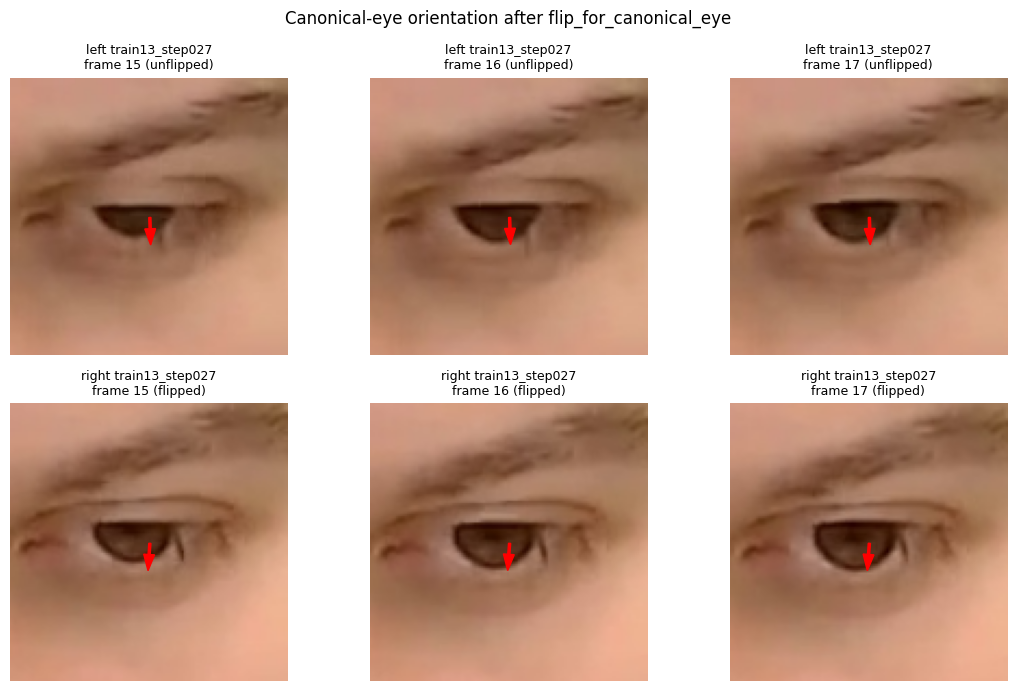

In [13]:
def draw_arrow(ax, img, vector, title):
    ax.imshow(img)
    h, w = img.shape[:2]
    cx, cy = w / 2, h / 2
    scale = 40
    ax.arrow(
        cx, cy, vector[0] * scale, vector[1] * scale,
        color="red", width=1.0, head_width=5, length_includes_head=True,
    )
    ax.set_title(title, fontsize=9)
    ax.axis("off")


fig, axes = plt.subplots(2, 3, figsize=(11, 7))

for i, (exp_key, frame) in enumerate(left_samples):
    img, vec = load_normalized_sample(bundle, exp_key, frame, "left")
    canon_img, canon_vec = flip_for_canonical_eye(img, vec, "left")
    draw_arrow(axes[0, i], canon_img, canon_vec, f"left {exp_key}\nframe {frame} (unflipped)")

for i, (exp_key, frame) in enumerate(right_samples):
    img, vec = load_normalized_sample(bundle, exp_key, frame, "right")
    canon_img, canon_vec = flip_for_canonical_eye(img, vec, "right")
    draw_arrow(axes[1, i], canon_img, canon_vec, f"right {exp_key}\nframe {frame} (flipped)")

fig.suptitle("Canonical-eye orientation after flip_for_canonical_eye")
fig.tight_layout()
fig.savefig("inspect_geometry_flip_output.png", dpi=100)
plt.show()

## 2. Before/after comparison for one right-eye sample

Shows the raw normalized patch (pre-flip) next to the canonical (post-flip) patch, confirming the mirror and the vector sign flip together.

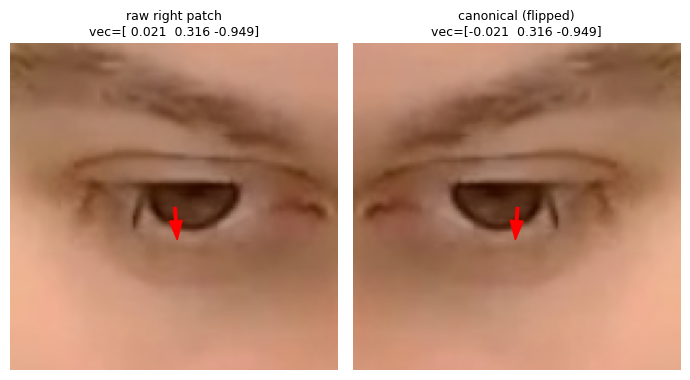

raw vector:       [ 0.02108261  0.31574604 -0.94860947]
canonical vector: [-0.02108261  0.31574604 -0.94860947]
x-component negated, y/z unchanged: OK


In [14]:
exp_key, frame = right_samples[0]
raw_img, raw_vec = load_normalized_sample(bundle, exp_key, frame, "right")
canon_img, canon_vec = flip_for_canonical_eye(raw_img, raw_vec, "right")

fig, axes = plt.subplots(1, 2, figsize=(7, 4))
draw_arrow(axes[0], raw_img, raw_vec, f"raw right patch\nvec={np.round(raw_vec, 3)}")
draw_arrow(axes[1], canon_img, canon_vec, f"canonical (flipped)\nvec={np.round(canon_vec, 3)}")
fig.tight_layout()
plt.show()

print("raw vector:      ", raw_vec)
print("canonical vector:", canon_vec)
assert canon_vec[0] == -raw_vec[0]
assert canon_vec[1] == raw_vec[1] and canon_vec[2] == raw_vec[2]
print("x-component negated, y/z unchanged: OK")

## 3. Correctness invariants on real samples

Same invariants as `tests/test_eye_crop_geometry.py`, but exercised against real, bundle-sourced images/vectors rather than synthetic ones — the strongest available check that the flip logic holds up outside of hand-built fixtures.

In [15]:
all_samples = [("left", ek, f) for ek, f in left_samples] + [("right", ek, f) for ek, f in right_samples]

for patch, exp_key, frame in all_samples:
    img, vec = load_normalized_sample(bundle, exp_key, frame, patch)

    canon_img, canon_vec = flip_for_canonical_eye(img, vec, patch)

    # (a) unit-norm preserved
    assert np.isclose(np.linalg.norm(canon_vec), 1.0, atol=1e-6), "lost unit norm"

    # (b) flip-of-flip is the identity (image + vector)
    img2, vec2 = flip_for_canonical_eye(canon_img, canon_vec, patch)
    assert np.array_equal(img2, img), "flip-of-flip did not recover the original image"
    assert np.allclose(vec2, vec, atol=1e-6), "flip-of-flip did not recover the original vector"

    # (c) left is untouched, right is mirrored
    if patch == "left":
        assert np.array_equal(canon_img, img)
        assert np.allclose(canon_vec, vec)
    else:
        assert np.array_equal(canon_img, img[:, ::-1])
        assert canon_vec[0] == -vec[0]

    print(f"{patch:5s} {exp_key} frame {frame}: OK  (|v|={np.linalg.norm(canon_vec):.6f})")

print("\nAll invariants hold on real bundle samples.")

left  train13_step027 frame 15: OK  (|v|=1.000000)
left  train13_step027 frame 16: OK  (|v|=1.000000)
left  train13_step027 frame 17: OK  (|v|=1.000000)
right train13_step027 frame 15: OK  (|v|=1.000000)
right train13_step027 frame 16: OK  (|v|=1.000000)
right train13_step027 frame 17: OK  (|v|=1.000000)

All invariants hold on real bundle samples.


## 4. Eye-convention pitfall check

TechStack warns that `get_eye_coords_in_crop`'s `left`/`right` labels are the **opposite** convention from the `W`-patch name (`left_W` centres the eye that appears on the image-**right**). This cell demonstrates why keying the flip off `get_eye_coords_in_crop` instead of the `W`-patch name would silently mirror half the dataset, and confirms `flip_for_canonical_eye`'s contract (it takes `eye` as an explicit string, so correctness here is entirely the caller's responsibility — the module itself does not read `get_eye_coords_in_crop` at all).

In [16]:
exp_key, frame = left_samples[0]
eye_coords = bundle.get_eye_coords_in_crop(exp_key, frame)
print("get_eye_coords_in_crop keys (opposite convention, do NOT use for flip decision):", list(eye_coords.keys()))
print("Correct source of truth: the patch name passed to get_warp_matrix(exp_key, patch) / get_normalized_gaze(exp_key, patch).")
print("flip_for_canonical_eye(image, vector, eye) is only ever called with that patch name, e.g. 'left'/'right' above.")

get_eye_coords_in_crop keys (opposite convention, do NOT use for flip decision): ['left', 'right']
Correct source of truth: the patch name passed to get_warp_matrix(exp_key, patch) / get_normalized_gaze(exp_key, patch).
flip_for_canonical_eye(image, vector, eye) is only ever called with that patch name, e.g. 'left'/'right' above.


## 5. Invalid-eye error path

In [17]:
try:
    flip_for_canonical_eye(np.zeros((128, 128, 3), dtype=np.uint8), np.array([0.0, 0.0, 1.0]), "center")
    raise AssertionError("expected ValueError")
except ValueError as e:
    print(f"Raised as expected: {e}")

Raised as expected: eye must be 'left' or 'right', got 'center'


## Conclusion

`flip_for_canonical_eye` in `src/eyenet/geometry.py` behaves correctly against real bundle data: left-eye samples pass through unchanged, right-eye samples are mirrored with the vector's x-component negated, flip-then-flip recovers the original exactly, and unit-norm is preserved throughout. No bug found — no fix was necessary.